In [1]:
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=yf.download("AAPL",start="2018-01-01",end="2019-12-31")
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.267086,40.276438,39.565813,39.776197,102223600
2018-01-03,40.260063,40.802382,40.196951,40.330191,118071600
2018-01-04,40.447071,40.549925,40.225002,40.332529,89738400
2018-01-05,40.907566,40.994055,40.451740,40.542905,94640000
2018-01-08,40.755634,41.050168,40.657453,40.755634,82271200


In [3]:
df["Close"]

Ticker,AAPL
Date,
2018-01-02,40.267086
2018-01-03,40.260063
2018-01-04,40.447071
2018-01-05,40.907566
2018-01-08,40.755634
...,...
2019-12-23,68.396263
2019-12-24,68.461273
2019-12-26,69.819588


In [4]:
df = df["Close"].squeeze().to_frame()

In [5]:
df.head()

,AAPL
Date,
2018-01-02,40.267086
2018-01-03,40.260063
2018-01-04,40.447071
2018-01-05,40.907566
2018-01-08,40.755634


In [6]:
df["Close in 10 changes"]=df["AAPL"].shift(-10)
df.head(20)

,AAPL,Close in 10 changes
Date,,
2018-01-02,40.267086,41.865990
2018-01-03,40.260063,41.903381
2018-01-04,40.447071,41.716377
2018-01-05,40.907566,41.375084
2018-01-08,40.755634,41.384434
2018-01-09,40.750957,40.725227
2018-01-10,40.741592,39.998264
2018-01-11,40.973026,40.091763
2018-01-12,41.396118,39.261921


In [7]:
df.tail(20)

,AAPL,Close in 10 changes
Date,,
2019-12-02,63.618149,67.399231
2019-12-03,62.483864,67.531685
2019-12-04,63.035339,67.370338
2019-12-05,63.960155,67.437767
2019-12-06,65.195602,67.298080
2019-12-09,64.282852,68.396263
2019-12-10,64.658592,68.461273
2019-12-11,65.210052,69.819588
2019-12-12,65.376244,69.793121


In [8]:
dfc=df.iloc[:-10,:]

In [9]:
dfc.head()

,AAPL,Close in 10 changes
Date,,
2018-01-02,40.267086,41.865990
2018-01-03,40.260063,41.903381
2018-01-04,40.447071,41.716377
2018-01-05,40.907566,41.375084
2018-01-08,40.755634,41.384434


In [10]:
df.reset_index(inplace=True)

In [11]:
df.head()

,Date,AAPL,Close in 10 changes
0,2018-01-02,40.267086,41.865990
1,2018-01-03,40.260063,41.903381
2,2018-01-04,40.447071,41.716377
3,2018-01-05,40.907566,41.375084
4,2018-01-08,40.755634,41.384434


In [12]:
x=dfc.iloc[:,0].values.reshape(dfc.shape[0],1)
y=dfc.iloc[:,1].values

In [13]:
x_train,x_test,y_tran,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [14]:
rf=RandomForestRegressor(n_estimators=500)
rf.fit(x_train,y_tran)
y_pred=rf.predict(x_test)
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(2.8779809462196524)

In [15]:
y_act_10=dfc.iloc[-10:,:]["Close in 10 changes"].values
print(y_act_10)

[67.39923096 67.53168488 67.37033844 67.43776703 67.29808044 68.39626312
 68.46127319 69.81958771 69.79312134 70.20733643]


In [16]:
y_pred_10=rf.predict(dfc.iloc[-10:,:]["AAPL"].values.reshape(10,1))

In [17]:
print(y_pred_10)

[66.52464567 66.27056105 66.15931951 65.96041997 68.10972322 65.60869998
 67.39806548 69.24541295 69.53728494 69.94149826]


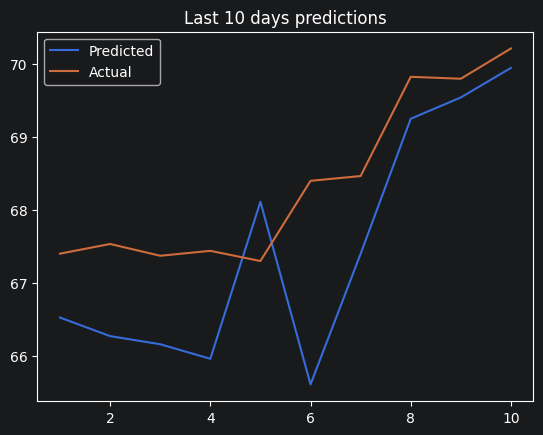

In [18]:
plt.plot(range(1,11),y_pred_10)
plt.plot(range(1,11),y_act_10)
plt.legend(["Predicted","Actual"])
plt.title("Last 10 days predictions")
plt.show()